# ESG 친환경 보험 인수모델 — 제조기업 이득 분석

**입력 파일**: `학술제시트_520_아마최종.xlsx`

**목적**: 친환경 보험 인수모델 도입 시 제조기업이 누리는 보험료 절감 효과를 정량화

**핵심 지표**: 보험료 절감액 = `EP_구 - EP_신`

**할인율**: r = 2.7% (파일 명시 "V1 NPV (r=2.7%)" 기준)

## 분석할 시트
1. `3. 분석 및 모델링` — 0시점 기업별 분석 결과 (47개사)
2. `5. 통합` — 연도별 장기 시뮬레이션 결과 (36개 연도, t=0~35)

## 1. 라이브러리 임포트 및 한글 폰트 설정

In [9]:
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# 한글 폰트 (시스템에 맞게 조정)
# Mac: 'AppleGothic' / Windows: 'Malgun Gothic' / Linux: 'NanumGothic' 또는 'Noto Sans CJK KR'
mpl.rcParams['font.family'] = 'Malgun Gothic'  # 환경에 맞게 변경
mpl.rcParams['axes.unicode_minus'] = False

INPUT = '학술제시트_520_아마최종.xlsx'
R_DISC = 0.027  # V1 NPV 할인율 (파일 명시)

## 2. 데이터 로드: 0시점 기업별 (시트 "3. 분석 및 모델링")

In [10]:
wb = openpyxl.load_workbook(INPUT, data_only=True)
ws3 = wb['3. 분석 및 모델링']

rows = []
for i in range(2, ws3.max_row + 1):
    row = [c.value for c in ws3[i]]
    if row[0] and row[0] != '합계 (Total)':
        rows.append({
            'name':     row[0],   # 기업명
            'industry': row[1],   # 산업군
            'Ei':       row[2],   # 실질 담보액
            'rho':      row[6],   # 상대 탄소집약도 ρ
            'M':        row[7],   # 평균 전환노력
            'DF':       row[8],   # 할인팩터
            'EP_old':   row[9],   # 경과보험료 구
            'EP_new':   row[10],  # 경과보험료 신
        })
df0 = pd.DataFrame(rows)
df0['savings']      = df0['EP_old'] - df0['EP_new']        # 보험료 절감액
df0['savings_rate'] = 1 - df0['EP_new'] / df0['EP_old']    # 보험료 절감률
df0['category']    = np.where(df0['DF'] < 0.999, '할인',
                       np.where(df0['DF'] > 1.001, '할증', '중립'))
df0.head()

,name,industry,Ei,rho,M,DF,EP_old,EP_new,savings,savings_rate,category
0,삼성전자,전기,1943346,0.564467,0.044444,0.933779,2147.561965,2005.348109,142.213856,0.066221,할인
1,SK하이닉스,전기,611583,0.834662,0.091307,0.900426,675.851027,608.553963,67.297064,0.099574,할인
2,한미반도체,금속기계기구,2353,0.000000,0.000000,0.950000,1.127318,1.070952,0.056366,0.050000,할인
3,삼성전기,전기,66748,1.487615,0.046324,0.978057,73.762195,72.143642,1.618553,0.021943,할인
4,LG전자,전기,238903,0.039453,0.118200,0.833772,264.008054,220.122645,43.885409,0.166228,할인


## 3. 데이터 로드: 장기 시계열 (시트 "5. 통합")

In [3]:
ws5 = wb['5. 통합']
ts_rows = []
for i in range(3, ws5.max_row + 1):
    row = [c.value for c in ws5[i]]
    if isinstance(row[0], (int, float)):
        ts_rows.append({
            't':      int(row[0]),  # 연도
            'EP_old': row[1],       # 구모델 EP
            'EP_new': row[5],       # 신모델 EP
        })
dft = pd.DataFrame(ts_rows)
dft['savings']        = dft['EP_old'] - dft['EP_new']
dft['cum_savings']    = dft['savings'].cumsum()
dft['pv_savings']     = dft['savings'] / (1 + R_DISC) ** dft['t']
dft['cum_pv_savings'] = dft['pv_savings'].cumsum()
dft.head()

,t,EP_old,EP_new,savings,cum_savings,pv_savings,cum_pv_savings
0,0,7523.951406,6914.766316,609.185091,609.185091,609.185091,609.185091
1,1,7824.909463,7160.598116,664.311347,1273.496438,646.846492,1256.031582
2,2,8137.905841,7413.800328,724.105513,1997.601951,686.532287,1942.563870
3,3,8463.422075,7674.330566,789.091509,2786.693460,728.477327,2671.041197
4,4,8801.958958,7942.021391,859.937567,3646.631027,773.010063,3444.051260


## 4. Part 1: 0시점 제조기업 이득

In [11]:
summary = {
    '분석 기업 수':       len(df0),
    '총 EP_구':           df0['EP_old'].sum(),
    '총 EP_신':           df0['EP_new'].sum(),
    '총 절감액':          df0['savings'].sum(),
    '총 절감률 (%)':      (1 - df0['EP_new'].sum()/df0['EP_old'].sum())*100,
    '할인 기업 수 (DF<1)': (df0['category']=='할인').sum(),
    '할증 기업 수 (DF>1)': (df0['category']=='할증').sum(),
}
for k, v in summary.items():
    print(f'{k:>20}: {v:>12,.2f}' if isinstance(v,(int,float)) else f'{k}: {v}')

print('\n— 절감액 상위 5사 —')
print(df0.nlargest(5, 'savings')[['name','industry','EP_old','EP_new','savings','DF','rho','M']].to_string(index=False))
print('\n— 할증 상위 5사 —')
print(df0.nsmallest(5, 'savings')[['name','industry','EP_old','EP_new','savings','DF','rho','M']].to_string(index=False))

             분석 기업 수:        47.00
              총 EP_구:     7,523.95
              총 EP_신:     6,914.77
               총 절감액:       609.19
           총 절감률 (%):         8.10
할인 기업 수 (DF<1): 34
할증 기업 수 (DF>1): 13

— 절감액 상위 5사 —
  name industry      EP_old      EP_new    savings       DF      rho        M
  한국전력       전기 1626.358704 1301.086963 325.271741 0.800000 0.106704 0.160016
  삼성전자       전기 2147.561965 2005.348109 142.213856 0.933779 0.564467 0.044444
SK하이닉스       전기  675.851027  608.553963  67.297064 0.900426 0.834662 0.091307
  LG전자       전기  264.008054  220.122645  43.885409 0.833772 0.039453 0.118200
   현대차   금속기계기구  210.523408  168.418726  42.104682 0.800000 0.077597 0.193110

— 할증 상위 5사 —
    name industry     EP_old     EP_new    savings       DF      rho         M
POSCO홀딩스   금속기계기구 206.640796 244.679185 -38.038389 1.184080 7.014224  0.116631
      기아   금속기계기구 103.641394 124.369673 -20.728279 1.200000 0.042818 -2.588138
    현대제철   금속기계기구  92.758679 111.310414 -18.551736 1.

## 5. Part 2: 장기 (35년) 제조기업 이득

In [12]:
key_years = [0, 5, 10, 20, 30, 35]
print(dft[dft['t'].isin(key_years)][['t','EP_old','EP_new','savings','cum_savings','cum_pv_savings']].to_string(index=False))

last = dft.iloc[-1]
print(f"\n35년 누적 절감액 (미할인) : {last['cum_savings']:>12,.2f}")
print(f"35년 누적 절감액 (PV)    : {last['cum_pv_savings']:>12,.2f}")
print(f"증가 배율 (35년/0년)     : {last['savings']/dft['savings'].iloc[0]:>12.2f} x")

 t       EP_old       EP_new     savings  cum_savings  cum_pv_savings
 0  7523.951406  6914.766316  609.185091   609.185091      609.185091
 5  9154.037316  8216.873362  937.163954  4583.794981     4264.333593
10 11137.286069  9726.076413 1411.209656 10638.810728     9139.546004
20 16485.904054 13784.533348 2701.370705 31523.182682    22808.606735
30 24403.165257 20037.835143 4365.330114 67399.998124    40864.053583
35 29690.181838 24114.595402 5575.586436 93089.081907    51512.001072

35년 누적 절감액 (미할인) :    93,089.08
35년 누적 절감액 (PV)    :    51,512.00
증가 배율 (35년/0년)     :         9.15 x


## 6. 시각화

PPT에 들어갈 4종 그래프를 차례로 생성합니다.

In [13]:
COLOR_DISC  = '#2E7D32'
COLOR_SURC  = '#C62828'
COLOR_ACC   = '#1565C0'
n_disc  = (df0['category']=='할인').sum()
n_surch = (df0['category']=='할증').sum()

### Chart 1: 기업별 보험료 절감액 (막대그래프)

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_97199/515141243.py:11: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_97199/515141243.py:11: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_97199/515141243.py:11: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_97199/515141243.py:11: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  ax.grid(axis='y', alpha=0.3); plt.tight_

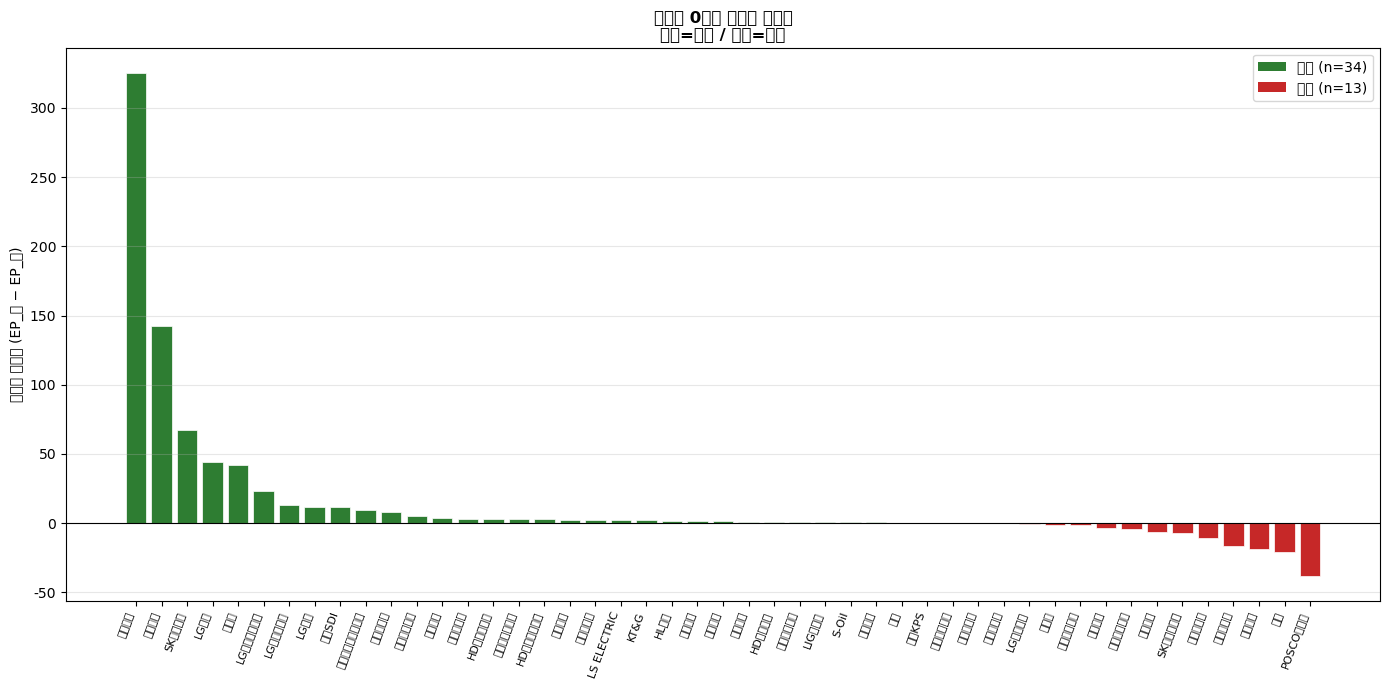

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
d1 = df0.sort_values('savings', ascending=False).reset_index(drop=True)
colors = [COLOR_DISC if s > 0 else COLOR_SURC for s in d1['savings']]
ax.bar(range(len(d1)), d1['savings'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(d1))); ax.set_xticklabels(d1['name'], rotation=70, fontsize=8, ha='right')
ax.set_ylabel('보험료 절감액 (EP_구 − EP_신)')
ax.set_title('기업별 0시점 보험료 절감액\n양수=절감 / 음수=할증', fontweight='bold')
ax.legend(handles=[Patch(facecolor=COLOR_DISC, label=f'할인 (n={n_disc})'),
                   Patch(facecolor=COLOR_SURC, label=f'할증 (n={n_surch})')])
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### Chart 2: 연도별 전체 보험료 절감액 (line + area)

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_97199/3049828041.py:8: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
/var/folders/h6/c563qbpd3dz735x4bqtwkzpr0000gn/T/ipykernel_97199/3049828041.py:8: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
findfont: Font family 'Malgun Gothic' not fo

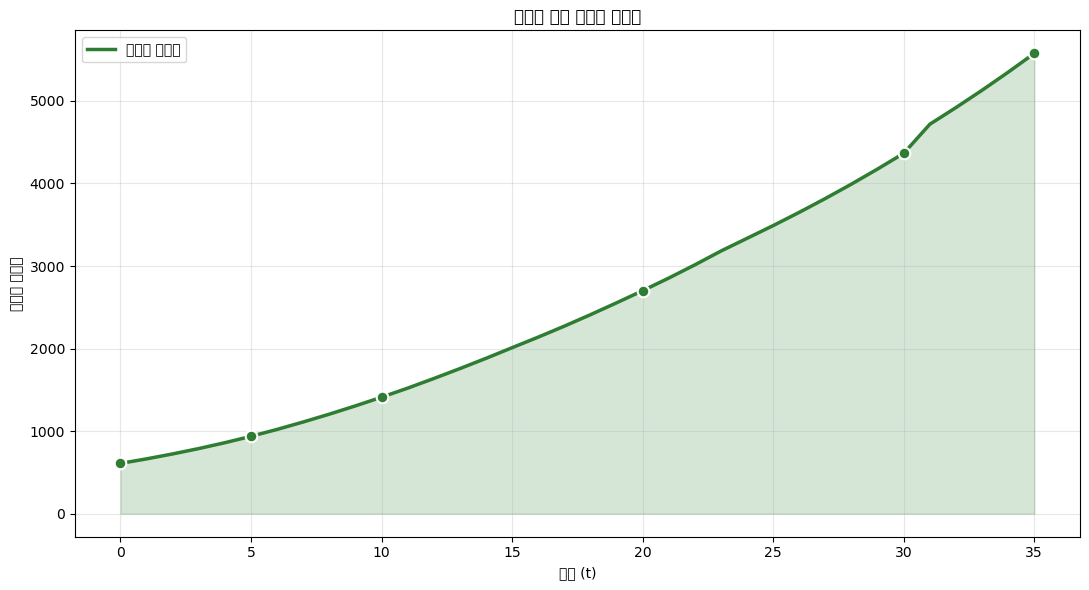

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(dft['t'], 0, dft['savings'], alpha=0.20, color=COLOR_DISC)
ax.plot(dft['t'], dft['savings'], '-', color=COLOR_DISC, linewidth=2.5, label='연도별 절감액')
ax.scatter(dft['t'].iloc[[0,5,10,20,30,35]], dft['savings'].iloc[[0,5,10,20,30,35]],
           color=COLOR_DISC, s=70, zorder=5, edgecolor='white', linewidth=1.5)
ax.set_xlabel('연도 (t)'); ax.set_ylabel('보험료 절감액')
ax.set_title('연도별 전체 보험료 절감액', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

### Chart 2b: 누적 절감액 (미할인 vs 현재가치)

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(dft['t'], dft['cum_savings'],    '-',  color=COLOR_DISC, linewidth=2.5, label='누적 절감액 (미할인)')
ax.plot(dft['t'], dft['cum_pv_savings'], '--', color=COLOR_ACC,  linewidth=2.5, label=f'누적 절감액 (PV, r={R_DISC*100:.1f}%)')
ax.set_xlabel('연도 (t)'); ax.set_ylabel('누적 보험료 절감액')
ax.set_title('35년 누적 제조기업 보험료 절감액', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

### Chart 3: 할인 vs 할증 기업 수

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
cats = [f'할인 (DF<1)\nn={n_disc}', f'할증 (DF>1)\nn={n_surch}']
vals = [n_disc, n_surch]
bars = ax.bar(cats, vals, color=[COLOR_DISC, COLOR_SURC], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.7, f'{v}사 ({v/len(df0)*100:.1f}%)',
            ha='center', fontweight='bold')
ax.set_ylabel('기업 수')
ax.set_title(f'0시점 할인/할증 기업 수 (전체 {len(df0)}사)', fontweight='bold')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### Chart 4: ρ – M – 보험료 절감률 산점도

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(df0['M'], df0['rho'],
                c=df0['savings_rate']*100, cmap='RdYlGn',
                s=np.sqrt(df0['EP_old'])*8 + 30,
                edgecolor='black', linewidth=0.6, alpha=0.85,
                vmin=-20, vmax=20)
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('보험료 절감률 (1 − DF) %')
label_pts = pd.concat([df0.nlargest(5,'savings'), df0.nsmallest(5,'savings')]).drop_duplicates('name')
for _, r in label_pts.iterrows():
    ax.annotate(r['name'], (r['M'], r['rho']), fontsize=8,
                xytext=(5,5), textcoords='offset points')
ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='산업 평균 ρ=1')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5, label='전환노력 M=0')
ax.set_xlabel('전환노력 M'); ax.set_ylabel('상대 탄소집약도 ρ')
ax.set_title('전환노력 – 탄소집약도 – 보험료 절감률 관계', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 7. 핵심 메시지

- **0시점**: 47개 제조기업 중 **34개사 (72.3%)**가 보험료 할인, 평균 절감률 **8.10%**.
- **35년 누적**: 미할인 기준 약 **93,089** / 현재가치(r=2.7%) 기준 **51,512**의 보험료 절감.
- **인센티브 구조**: 탄소집약도가 낮거나 전환노력이 큰 기업이 보험료 할인을 받음.
  POSCO홀딩스·현대제철 등 탄소집약도가 높은 기업과 기아·SK이노베이션처럼 전환노력 음수 기업은 할증.